In [1]:
# 1. Load & Inspect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/datasets/LeadScoring.csv')
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nTarget Distribution:\n{df['Converted'].value_counts(normalize=True)}")
df.head()

Shape: (9240, 37)

Data Types:
Prospect ID                                       object
Lead Number                                        int64
Lead Origin                                       object
Lead Source                                       object
Do Not Email                                      object
Do Not Call                                       object
Converted                                          int64
TotalVisits                                      float64
Total Time Spent on Website                        int64
Page Views Per Visit                             float64
Last Activity                                     object
Country                                           object
Specialization                                    object
How did you hear about X Education                object
What is your current occupation                   object
What matters most to you in choosing a course     object
Search                                            object


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [4]:
# 2. Statistical Summary
df.describe()
df.nunique()

,0
Prospect ID,9240
Lead Number,9240
Lead Origin,5
Lead Source,21
Do Not Email,2
Do Not Call,2
Converted,2
TotalVisits,41
Total Time Spent on Website,1731
Page Views Per Visit,114


In [5]:
# Missing Value Analysis
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Feature': missing_pct.index,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing %'] > 0])

                                          Feature  Missing %
25                                   Lead Quality  51.590909
31                     Asymmetrique Profile Index  45.649351
32                    Asymmetrique Activity Score  45.649351
30                    Asymmetrique Activity Index  45.649351
33                     Asymmetrique Profile Score  45.649351
24                                           Tags  36.287879
15  What matters most to you in choosing a course  29.318182
28                                   Lead Profile  29.318182
14                What is your current occupation  29.112554
11                                        Country  26.634199
13             How did you hear about X Education  23.885281
12                                 Specialization  15.562771
29                                           City  15.367965
9                            Page Views Per Visit   1.482684
7                                     TotalVisits   1.482684
10                      

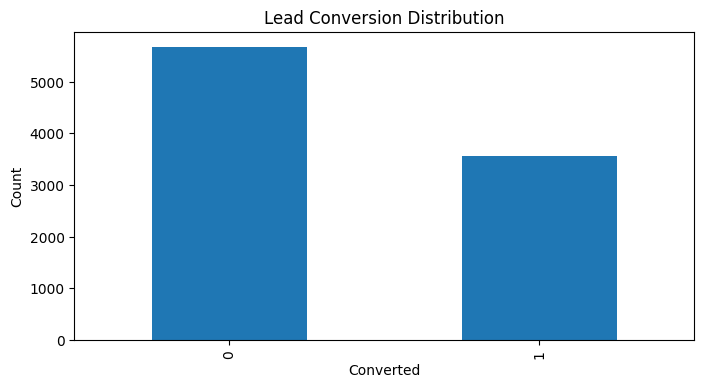

In [6]:
plt.figure(figsize=(8, 4))
df['Converted'].value_counts().plot(kind='bar')
plt.title('Lead Conversion Distribution')
plt.ylabel('Count')
plt.xlabel('Converted')
plt.show()

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corrwith(df['Converted']).sort_values(ascending=False)
print("\nTop 10 Features by Correlation with Conversion:")
print(correlations.head(10))


Top 10 Features by Correlation with Conversion:
Converted                      1.000000
Total Time Spent on Website    0.362483
Asymmetrique Profile Score     0.218571
Asymmetrique Activity Score    0.167962
TotalVisits                    0.030395
Lead Number                    0.025157
Page Views Per Visit          -0.003328
dtype: float64


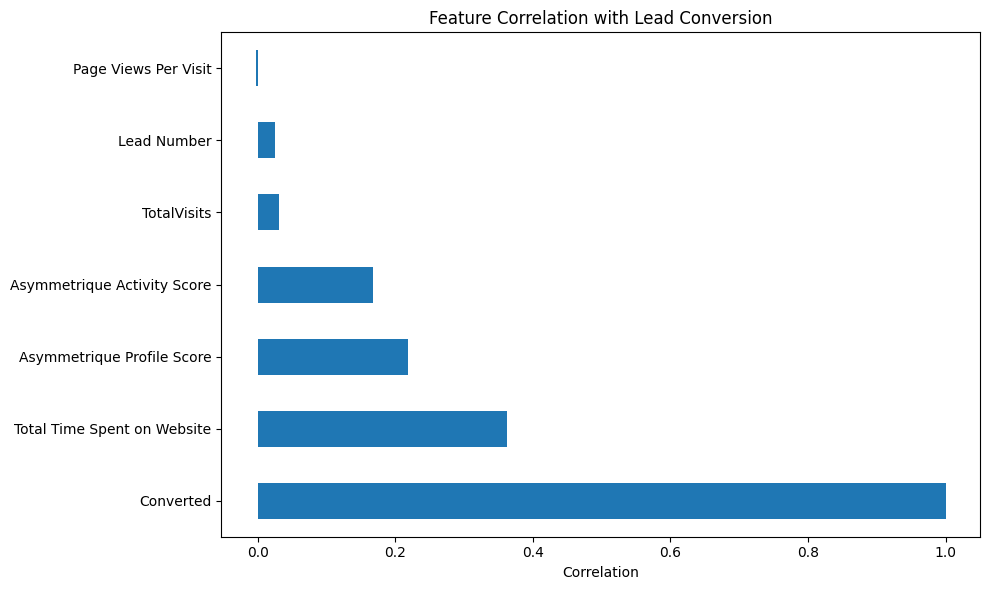

In [8]:
plt.figure(figsize=(10, 6))
correlations.head(15).plot(kind='barh')
plt.title('Feature Correlation with Lead Conversion')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

In [9]:
# 6. Categorical Features Analysis
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col} - Value Counts:")
    print(df[col].value_counts())

    # Conversion rate by category
    conv_by_cat = df.groupby(col)['Converted'].agg(['sum', 'count', 'mean'])
    conv_by_cat.columns = ['Conversions', 'Total Leads', 'Conversion Rate']
    print(conv_by_cat.sort_values('Conversion Rate', ascending=False))


Prospect ID - Value Counts:
Prospect ID
571b5c8e-a5b2-4d57-8574-f2ffb06fdeff    1
7927b2df-8bba-4d29-b9a2-b6e0beafe620    1
2a272436-5132-4136-86fa-dcc88c88f482    1
8cc8c611-a219-4f35-ad23-fdfd2656bd8a    1
0cc2df48-7cf4-4e39-9de9-19797f9b38cc    1
                                       ..
6d143c0e-abae-425f-a2c0-52c2946cbd45    1
8247051c-f838-4a41-b39c-1f0b44c3d5e6    1
b3455e2e-8236-478a-b1aa-666ad3381722    1
da8c5ce5-52b5-4a4e-bf75-e533d2aca52c    1
d2055a36-b268-43a0-beeb-9a715f6a660d    1
Name: count, Length: 9240, dtype: int64
                                      Conversions  Total Leads  \
Prospect ID                                                      
ffec8e24-0c99-4345-89f1-e3ad6689764f            1            1   
000104b9-23e4-4ddc-8caa-8629fe8ad7f4            1            1   
ffe36030-d068-4372-8172-9c0ddec4b011            1            1   
ffd5ccff-8ac4-4c03-ba78-4beb7e8974de            1            1   
ff9028a4-96b7-40ba-b615-f69054cccd07            1            

In [10]:
# 7. Outlier Detection
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"\n{col}: {len(outliers)} outliers detected")


TotalVisits: 267 outliers detected

Page Views Per Visit: 360 outliers detected

Asymmetrique Activity Score: 716 outliers detected


In [11]:
# 8. Data Quality Report
print("\n=== DATA QUALITY SUMMARY ===")
print(f"Total Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Class Imbalance Ratio: {(1 - df['Converted'].mean()) / df['Converted'].mean():.2f}:1")
# Save processed report
df.to_csv('/content/drive/MyDrive/datasets/eda_summary.csv', index=False)


=== DATA QUALITY SUMMARY ===
Total Records: 9240
Total Features: 37
Duplicate Rows: 0
Class Imbalance Ratio: 1.59:1


Checkpoint 1: EDA Completion Checklist

[ ] Dataset loaded and inspected

[ ] Target variable distribution documented

[ ] Missing values strategy defined

[ ] Top 15 correlated features identified

[ ] Outliers documented

[ ] Categorical features understood

[ ] Initial hypothesis: Which features signal
high-quality leads?

In [12]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Handle Missing Values
def handle_missing_values(df):
    """
    Strategy: Fill numerical with median, categorical with mode
    """
    df_clean = df.copy()

    # Numerical: median
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df_clean[col].isnull().sum() > 0:
            # Avoid inplace=True to prevent FutureWarning
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # Categorical: mode or 'Unknown'
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            # Avoid inplace=True to prevent FutureWarning
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Unknown')

    return df_clean

df_clean = handle_missing_values(df)
print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Missing values after cleaning: 0


In [13]:
# 2. Feature Engineering
def engineer_features(df):
    """
    Create new features that capture lead quality
    """
    df_eng = df.copy()

    # Feature 1: Website Engagement Score (combining TotalVisits and Total Time Spent on Website)
    if 'TotalVisits' in df_eng.columns and 'Total Time Spent on Website' in df_eng.columns:
        # Handle potential division by zero if max is 0 for normalization
        max_visits = df_eng['TotalVisits'].max()
        max_time_spent = df_eng['Total Time Spent on Website'].max()

        normalized_visits = (df_eng['TotalVisits'] / max_visits).fillna(0) if max_visits != 0 else 0
        normalized_time_spent = (df_eng['Total Time Spent on Website'] / max_time_spent).fillna(0) if max_time_spent != 0 else 0

        df_eng['Website_Engagement_Score'] = normalized_visits * 0.5 + normalized_time_spent * 0.5

    # Feature 2: Page Views Per Visit Score (normalized)
    if 'Page Views Per Visit' in df_eng.columns:
        max_page_views = df_eng['Page Views Per Visit'].max()
        df_eng['Page_Views_Score'] = (df_eng['Page Views Per Visit'] / max_page_views).fillna(0) if max_page_views != 0 else 0

    # Feature 3: No Contact Preference (Binary: 1 if 'Do Not Email' or 'Do Not Call' is 'Yes')
    if 'Do Not Email' in df_eng.columns and 'Do Not Call' in df_eng.columns:
        df_eng['No_Contact_Preference'] = ((df_eng['Do Not Email'] == 'Yes') | (df_eng['Do Not Call'] == 'Yes')).astype(int)

    # Feature 4: Recent SMS Activity and Email Opened Flags from 'Last Notable Activity'
    if 'Last Notable Activity' in df_eng.columns:
        df_eng['SMS_Sent_Flag'] = (df_eng['Last Notable Activity'] == 'SMS Sent').astype(int)
        df_eng['Email_Opened_Flag'] = (df_eng['Last Notable Activity'] == 'Email Opened').astype(int)

    # Feature 5: Lead Quality Score (mapping categorical 'Lead Quality' to numerical)
    if 'Lead Quality' in df_eng.columns:
        lead_quality_mapping = {
            'High in Relevance': 5,
            'Might be Unreachable': 4,
            'Not Sure': 3,
            'Poor': 2,
            'Worst': 1
        }
        df_eng['Lead_Quality_Score'] = df_eng['Lead Quality'].map(lead_quality_mapping).fillna(3) # Fill any unmapped with 'Not Sure' score

    # Feature 6: Is_Referral (Binary: 1 if Lead Source indicates a referral)
    if 'Lead Source' in df_eng.columns:
        df_eng['Is_Referral'] = ((df_eng['Lead Source'] == 'Referral Sites') | (df_eng['Lead Source'] == 'Through Recommendations')).astype(int)

    # Feature 7: Is_Organic_Search (Binary: 1 if Lead Source is 'Organic Search')
    if 'Lead Source' in df_eng.columns:
        df_eng['Is_Organic_Search'] = (df_eng['Lead Source'] == 'Organic Search').astype(int)

    # Feature 8: Total Asymmetrique Score (combining Asymmetrique Activity Score and Asymmetrique Profile Score)
    if 'Asymmetrique Activity Score' in df_eng.columns and 'Asymmetrique Profile Score' in df_eng.columns:
        df_eng['Total_Asymmetrique_Score'] = df_eng['Asymmetrique Activity Score'] + df_eng['Asymmetrique Profile Score']
        # Fix for FutureWarning: Avoid chained assignment
        df_eng['Total_Asymmetrique_Score'] = df_eng['Total_Asymmetrique_Score'].fillna(df_eng['Total_Asymmetrique_Score'].median())


    return df_eng

df_eng = engineer_features(df_clean)
print("New features created:", df_eng.shape[1] - df_clean.shape[1])


New features created: 9


In [14]:
# 3. Encode Categorical Variables
from sklearn.preprocessing import OneHotEncoder

def encode_categoricals(df, categorical_cols, drop_first=True):
    """One-hot encode categorical features"""
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=drop_first)
    return df_encoded

categorical_cols = df_eng.select_dtypes(include=['object']).columns.tolist()
if 'Converted' in categorical_cols:  # If target is encoded
    categorical_cols.remove('Converted')

df_encoded = encode_categoricals(df_eng, categorical_cols)
print(f"Shape after encoding: {df_encoded.shape}")

Shape after encoding: (9240, 9434)


In [15]:
# 4. Handle Class Imbalance (if needed)
X = df_encoded.drop('Converted', axis=1)
y = df_encoded['Converted']

if y.value_counts().min() / y.value_counts().max() < 0.3:  # If ratio < 0.3:1
    print("Class imbalance detected. Applying SMOTE...")
    smote = SMOTE(random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X, y)
    print(f"After SMOTE: {y_balanced.value_counts()}")
else:
    X_balanced, y_balanced = X, y
    print("Class distribution acceptable. No SMOTE applied.")

Class distribution acceptable. No SMOTE applied.


In [16]:
# 5. Train-Test-Validation Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train conversion rate: {y_train.mean():.2%}")
print(f"Val conversion rate: {y_val.mean():.2%}")
print(f"Test conversion rate: {y_test.mean():.2%}")


Train: (6468, 9433), Val: (1386, 9433), Test: (1386, 9433)
Train conversion rate: 38.54%
Val conversion rate: 38.53%
Test conversion rate: 38.53%


In [17]:
# 6. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Save preprocessed data
np.save('/content/drive/MyDrive/datasets/X_train_scaled.npy', X_train_scaled)
np.save('/content/drive/MyDrive/datasets/X_val_scaled.npy', X_val_scaled)
np.save('/content/drive/MyDrive/datasets/X_test_scaled.npy', X_test_scaled)
np.save('/content/drive/MyDrive/datasets/y_train.npy', y_train.values)
np.save('/content/drive/MyDrive/datasets/y_val.npy', y_val.values)
np.save('/content/drive/MyDrive/datasets/y_test.npy', y_test.values)

In [19]:
# Save feature names for later use
feature_names = X_train.columns.tolist()
import json
with open('/content/drive/MyDrive/datasets/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

In [20]:
# Save scaler
import pickle
with open('/content/drive/MyDrive/datasets/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n✅ Preprocessing complete. Data saved.")


✅ Preprocessing complete. Data saved.


Checkpoint 2: Preprocessing Completion Checklist

[ ] Missing values handled

[ ] Feature engineering completed (new features created)

[ ] Categorical variables encoded

[ ] Class imbalance assessed and handled

[ ] Train/val/test split created (70/15/15)

[ ] Features scaled

[ ] Feature names saved

[ ] Scaler artifact saved


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [22]:
# Load preprocessed data
X_train_scaled = np.load('/content/drive/MyDrive/datasets/X_train_scaled.npy')
X_val_scaled = np.load('/content/drive/MyDrive/datasets/X_val_scaled.npy')
X_test_scaled = np.load('/content/drive/MyDrive/datasets/X_test_scaled.npy')
y_train = np.load('/content/drive/MyDrive/datasets/y_train.npy')
y_val = np.load('/content/drive/MyDrive/datasets/y_val.npy')
y_test = np.load('/content/drive/MyDrive/datasets/y_test.npy')

In [23]:
# 1. Define Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

In [24]:
# 2. Train and Evaluate
results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    # Train
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_val = model.predict(X_val_scaled)
    y_pred_test = model.predict(X_test_scaled)
    y_pred_proba_test = model.predict_proba(X_test_scaled)[:, 1]

    # Evaluate
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_scaled)[:, 1])
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val_scaled)[:, 1])
    test_auc = roc_auc_score(y_test, y_pred_proba_test)

    print(f"Train AUC: {train_auc:.4f}")
    print(f"Val AUC: {val_auc:.4f}")
    print(f"Test AUC: {test_auc:.4f}")
    print(f"\nTest Classification Report:")
    print(classification_report(y_test, y_pred_test))

    results[name] = {
        'model': model,
        'train_auc': train_auc,
        'val_auc': val_auc,
        'test_auc': test_auc,
        'y_pred_proba': y_pred_proba_test
    }


Training Logistic Regression...
Train AUC: 1.0000
Val AUC: 0.9585
Test AUC: 0.9578

Test Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       852
           1       0.90      0.80      0.85       534

    accuracy                           0.89      1386
   macro avg       0.89      0.87      0.88      1386
weighted avg       0.89      0.89      0.89      1386


Training Random Forest...
Train AUC: 1.0000
Val AUC: 0.9722
Test AUC: 0.9736

Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       852
           1       0.92      0.87      0.90       534

    accuracy                           0.92      1386
   macro avg       0.92      0.91      0.92      1386
weighted avg       0.92      0.92      0.92      1386


Training XGBoost...
Train AUC: 0.9989
Val AUC: 0.9814
Test AUC: 0.9783

Test Classification Report:
              precision  

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Train AUC: 0.9981
Val AUC: 0.9823
Test AUC: 0.9812

Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       852
           1       0.92      0.91      0.92       534

    accuracy                           0.94      1386
   macro avg       0.93      0.93      0.93      1386
weighted avg       0.94      0.94      0.94      1386



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [25]:
# 3. Model Comparison
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train AUC': [results[m]['train_auc'] for m in results.keys()],
    'Val AUC': [results[m]['val_auc'] for m in results.keys()],
    'Test AUC': [results[m]['test_auc'] for m in results.keys()]
})
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(comparison_df.to_string(index=False))


MODEL COMPARISON
              Model  Train AUC  Val AUC  Test AUC
Logistic Regression   1.000000 0.958549  0.957808
      Random Forest   1.000000 0.972230  0.973564
            XGBoost   0.998868 0.981400  0.978255
           LightGBM   0.998074 0.982336  0.981176


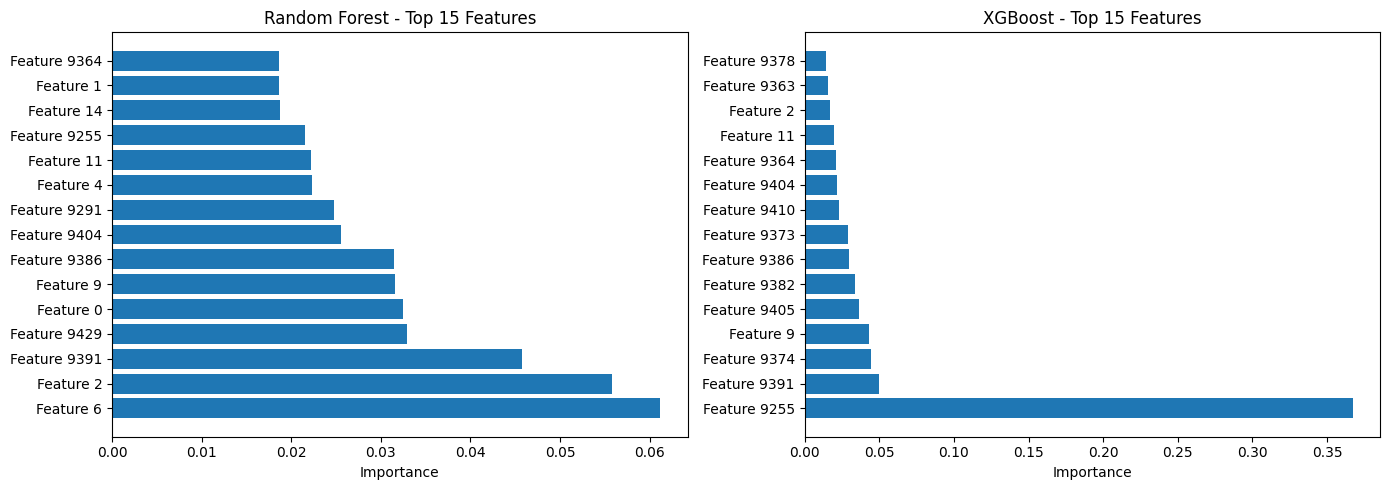

In [26]:
import os

# 4. Feature Importance (Tree-based models)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
rf_model = results['Random Forest']['model']
rf_importance = pd.DataFrame({
    'Feature': range(len(rf_model.feature_importances_)),
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

axes[0].barh(range(len(rf_importance)), rf_importance['Importance'])
axes[0].set_yticks(range(len(rf_importance)))
axes[0].set_yticklabels([f"Feature {i}" for i in rf_importance['Feature']])
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest - Top 15 Features')

# XGBoost
xgb_model = results['XGBoost']['model']
xgb_importance = pd.DataFrame({
    'Feature': range(len(xgb_model.feature_importances_)),
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

axes[1].barh(range(len(xgb_importance)), xgb_importance['Importance'])
axes[1].set_yticks(range(len(xgb_importance)))
axes[1].set_yticklabels([f"Feature {i}" for i in xgb_importance['Feature']])
axes[1].set_xlabel('Importance')
axes[1].set_title('XGBoost - Top 15 Features')

plt.tight_layout()

# Create the 'outputs' directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

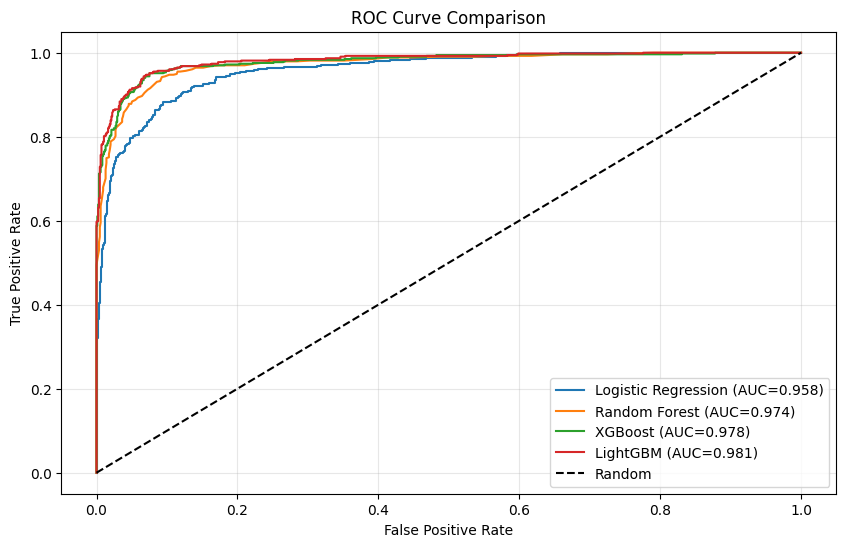

In [27]:
# 5. ROC Curves Comparison
plt.figure(figsize=(10, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['test_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('outputs/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# 6. Select Best Model
best_model_name = comparison_df.loc[comparison_df['Test AUC'].idxmax(), 'Model']
best_model = results[best_model_name]['model']
print(f"\n✅ Best Model: {best_model_name} (Test AUC: {results[best_model_name]['test_auc']:.4f})")


✅ Best Model: LightGBM (Test AUC: 0.9812)


In [29]:
# Save best model
import pickle
import os

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

with open('models/best_baseline_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

Checkpoint 3: Baseline Modeling Checklist

[ ] Multiple models trained (Logistic Regression, RF, XGBoost, LightGBM)

[ ] Performance metrics calculated (AUC, precision, recall, F1)

[ ] Feature importance analyzed

[ ] ROC curves plotted

[ ] Best baseline model identified

[ ] Model saved
